In [38]:
from pandas import read_csv as rd 

# **Program 1**

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [40]:
df=rd('EDAibm_hr_employee-attrition.csv')
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [41]:
num_val= df.select_dtypes(include='number').columns
cat_val= df.select_dtypes(exclude='number').columns

In [42]:
coln=input('enter the column name: ')
if coln in num_val:
    col=df[coln]
    mean=col.mean()
    median=col.median()
    mode=col.mode()
    std=col.std()
    var=col.var()
    range=col.max()-col.min()
    q1=col.quantile(0.25)
    q3=col.quantile(0.75)
    iqr=q3-q1
    lb=q1-(1.5*iqr)
    up=q3+(1.5*iqr)
    outliers=col[(col<lb) | (col>up)]
    print(f'Mean: {mean}\nMedian: {median}\nMode: {mode}\nStandard Deviation: {std}\nVariance: {var}\nRange: {range}\n')
    print(len(outliers))
else:
    print('wrong choice')

Mean: 36.923809523809524
Median: 36.0
Mode: 0    35
Name: Age, dtype: int64
Standard Deviation: 9.135373489136734
Variance: 83.45504878602227
Range: 42

0


[]

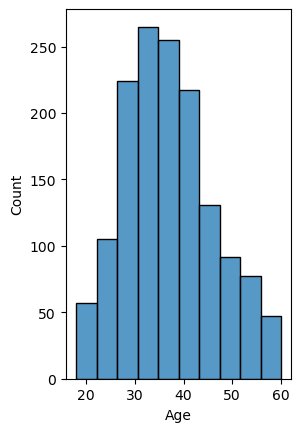

In [43]:
plt.subplot(1,2,1)
sns.histplot(data=col,kde=False,legend=False,bins=10)
plt.plot()

[]

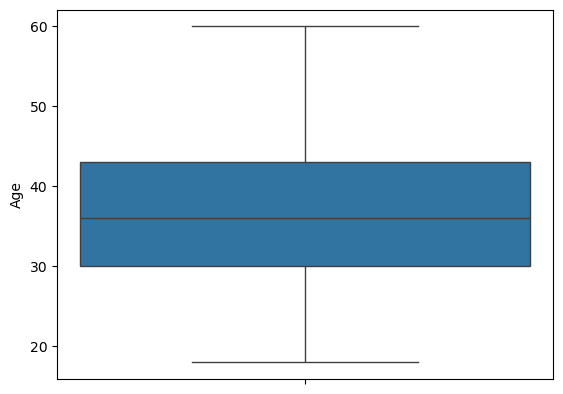

In [46]:
sns.boxplot(df[coln])
plt.plot()

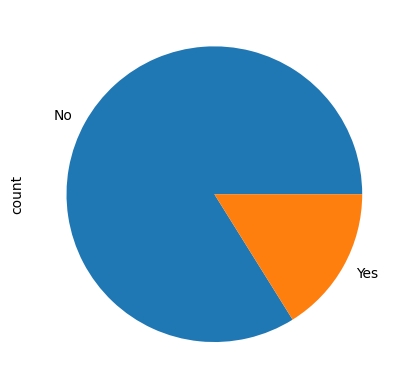

In [45]:
colc=input('enter the column name: ')
if colc in cat_val:
    col=df[colc].value_counts()
    cho=input('enter the type of plot you want: ')
    if cho.lower()=='bar':
        col.plot(kind='bar')
        plt.show()
    elif cho.lower()=='pie':
        col.plot(kind='pie')
        plt.show()
    else:
        print("Wrong choice")
else:
    print('wrong choice-outer')

# **Program 2**

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [63]:
df=sns.load_dataset('iris')
x='sepal_length'
y='petal_length'

In [64]:
corr=df[['sepal_length','sepal_width']].corr('pearson')
cov=df[['sepal_length','sepal_width']].cov()
print(f'Correlation: {corr}\nCovariance: {cov}')

Correlation:               sepal_length  sepal_width
sepal_length       1.00000     -0.11757
sepal_width       -0.11757      1.00000
Covariance:               sepal_length  sepal_width
sepal_length      0.685694    -0.042434
sepal_width      -0.042434     0.189979


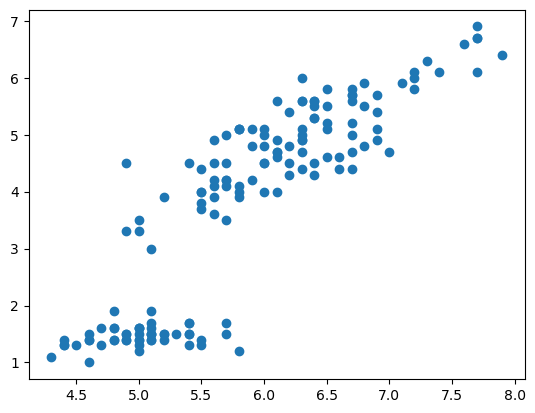

In [65]:
plt.scatter(df[x],df[y])

In [69]:
d=df.iloc[:,:-1]
cov=d.cov()
corr=d.corr()

<Axes: >

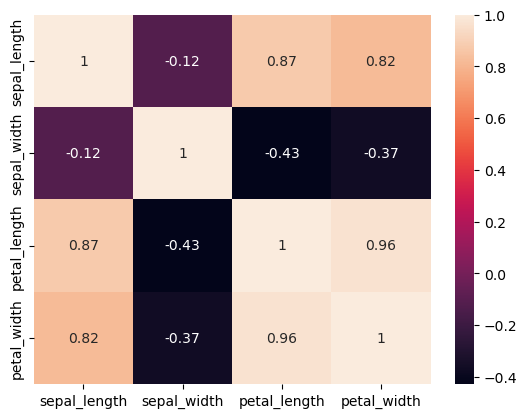

In [71]:
sns.heatmap(corr,annot=True)

# **Program 3**

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [74]:
iris=load_iris()
x=iris.data
y=iris.target

In [75]:
sc=StandardScaler()
tr=sc.fit_transform(x)

In [77]:
pc=PCA(n_components=2)
tpc=pc.fit_transform(tr)

In [84]:
df=pd.DataFrame(data=tpc,columns=["PC1","PC2"])
df["Species"]=y

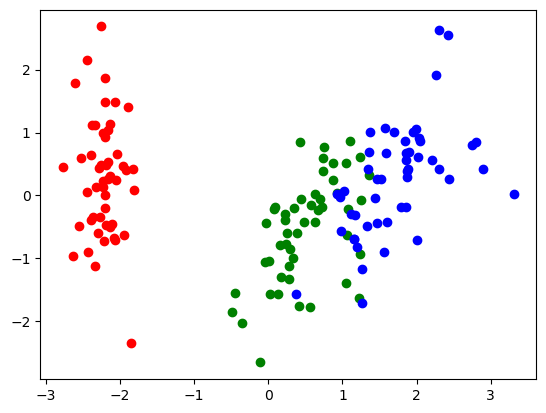

In [86]:
colors=['red','green','blue']
for i, color in zip([0, 1, 2], colors):
    plt.scatter(
        df[df['Species'] == i]['PC1'],
        df[df['Species'] == i]['PC2'],
        color=color,
        label=iris.target_names[i]
    )
plt.show()

# **Program 4**

In [90]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as ass, f1_score as f
from sklearn.model_selection import train_test_split as tts

In [126]:
iris = load_iris()
x=iris.data ; y= iris.target
k_values=[1,3,5]

In [127]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)

In [128]:
def neighbor(x_train,x_test,y_train,y_test,k_val,weighted=False):
    accu={}
    for k in k_val:
        if weighted:
            knn=KNeighborsClassifier(n_neighbors=k, weights='distance')
        else:
            knn=KNeighborsClassifier(n_neighbors=k,weights='uniform')
        
        knn.fit(x_train,y_train)
        y_pred=knn.predict(x_test)
        acc=ass(y_test,y_pred)
        f1=f(y_test,y_pred,average='weighted')
        accu[k]={'Accuracy Score':acc,
            'f1 Score': f1}
    return accu
    
        

In [133]:
wk=neighbor(x_train,x_test,y_train,y_test,k_values,weighted=True)
for i, met in wk.items():
    print(f"{i}={met['Accuracy Score']},{met['f1 Score']}")

1=1.0,1.0
3=1.0,1.0
5=1.0,1.0


In [134]:
nk=neighbor(x_train,x_test,y_train,y_test,k_values,weighted=False)
for i, met in wk.items():
    print(f"{i}={met['Accuracy Score']},{met['f1 Score']}")

1=1.0,1.0
3=1.0,1.0
5=1.0,1.0


In [138]:
for k in k_values:
    reg=nk[k]['Accuracy Score']
    wei=wk[k]['Accuracy Score']
    print(f'{k} {reg},{wei}')

1 1.0,1.0
3 1.0,1.0
5 1.0,1.0
